# ***MLP Project Comment Category Prediction***

In this project, the final category of the comment needs to be predicted based on the given features. It is a multi class classification problem as there are four categories assigned to the comments.

# ***Importing Libraries***

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns     
import numpy as np

In [103]:
#preprocessing
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

#model building
from sklearn.model_selection import StratifiedKFold,RandomizedSearchCV
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression 

#model metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

# ***Loading Data***

In [104]:
train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# ***Exploratory Data Analysis***

In [105]:
print("Shape of the train dataset is", train.shape)
print("Shape of the test dataset is",test.shape)

Shape of the train dataset is (198000, 15)
Shape of the test dataset is (102000, 14)


In [106]:
print("Columns in the train dataset")
for col in train.columns.tolist():
    print("\t",col) 
print("\n")
print("Columns in the test dataset")
for col in test.columns.tolist():
    print("\t",col) 

Columns in the train dataset
	 created_date
	 post_id
	 emoticon_1
	 emoticon_2
	 emoticon_3
	 upvote
	 downvote
	 if_1
	 if_2
	 race
	 religion
	 gender
	 disability
	 comment
	 label


Columns in the test dataset
	 created_date
	 post_id
	 emoticon_1
	 emoticon_2
	 emoticon_3
	 upvote
	 downvote
	 if_1
	 if_2
	 race
	 religion
	 gender
	 disability
	 comment


In [107]:
print("\tDatatype of each column in the train dataset")
print(train.dtypes)
print("\n")
print("\tDatatype of each column in the test dataset")
print(test.dtypes)

	Datatype of each column in the train dataset
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


	Datatype of each column in the test dataset
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
dtype: object



* The categorical features are race, religion, gender, disability(Boolean).
* The text features is the comment column.
* Remaining are the numerical features.
* Created date is of datetime type.


In [108]:
print("\tNumber of unique values in the train dataset are:")
print(train.nunique())
print("\n")
print("\tNumber of unique values in the test dataset are:")
print(test.nunique())

	Number of unique values in the train dataset are:
created_date    197996
post_id             52
emoticon_1          36
emoticon_2          10
emoticon_3          16
upvote             122
downvote            62
if_1                57
if_2                81
race                 6
religion             8
gender               5
disability           2
comment         197842
label                4
dtype: int64


	Number of unique values in the test dataset are:
created_date    101997
post_id             45
emoticon_1          29
emoticon_2           8
emoticon_3          16
upvote              97
downvote            47
if_1                37
if_2                70
race                 6
religion             8
gender               5
disability           2
comment         101952
dtype: int64


It can be seen that the categorical features have less number of unique values.

In [109]:
print("Number of counts for the categorical features for each category")
print('\n')
for i in ['race','religion','gender']:
    print(train[i].value_counts())
    print('\n')

Number of counts for the categorical features for each category


race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64


religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64


gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64




In [110]:
print("\t\tQuantitative statistics of the numerical columns in the train dataset")
print("\n")
#post_id and label are not considered
print(train.drop(columns=['post_id', 'label']).describe())
print("\n")
print("\t\tQuantitative statistics of the numerical columns in the test dataset")
print("\n")
print(test.drop(columns=['post_id']).describe())

		Quantitative statistics of the numerical columns in the train dataset


          emoticon_1     emoticon_2     emoticon_3         upvote  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        0.279768       0.048338       0.121071       2.607975   
std         1.023234       0.258477       0.481013       5.054763   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       0.000000       0.000000       3.000000   
max        47.000000      11.000000      17.000000     201.000000   

            downvote           if_1           if_2  
count  198000.000000  198000.000000  198000.000000  
mean        0.666394       1.906152       7.956212  
std         2.044335      25.635752      14.839464  
min         0.000000       0.000000       3.000000  
25%         0.000000       0.000000    


* Most of the features have mean greater than median.
* Means and standard deviation are identical across test and train dataset


In [111]:
print("\t\tDescriptive statistics of the categorical columns in the train dataset")
print("\n")
print(train.drop(columns=['created_date']).describe(include="object"))
print("\n")
print("\t\tDescriptive statistics of the categorical columns in the test dataset")
print("\n")
print(test.drop(columns=['created_date']).describe(include="object"))

		Descriptive statistics of the categorical columns in the train dataset


         race religion gender    comment
count   52577    52577  52577     197999
unique      6        8      5     197842
top      none     none   none  Exactly..
freq    39682    38249  36161          8


		Descriptive statistics of the categorical columns in the test dataset


         race religion gender comment
count   26731    26731  26731  102000
unique      6        8      5  101952
top      none     none   none   Troll
freq    20229    19542  18271       5


# ***Data Imputation***

In [112]:
print("\tNull values present in the train dataset are:")
print("\n")
print(train.isna().sum())
print("\n")
print("\tNull values present in the test dataset are:")
print("\n")
print(test.isna().sum())

	Null values present in the train dataset are:


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


	Null values present in the test dataset are:


created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


In [113]:
print("\tPercentage of null values present in the train dataset are:")
print("\n")
print(train.isna().mean()*100)
print("\n")
print("\tPercentage of null values present in the test dataset are:")
print("\n")
print(test.isna().mean()*100)

	Percentage of null values present in the train dataset are:


created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.445960
religion        73.445960
gender          73.445960
disability       0.000000
comment          0.000505
label            0.000000
dtype: float64


	Percentage of null values present in the test dataset are:


created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.793137
religion        73.793137
gender          73.793137
disability       0.000000
comment          0.000000
dtype: float64



* There is one null value in the comment column.
* The race, religion and gender columns have 74% of null values.


In [114]:
for df in [train, test]:
    #As there is only one null value in comment column it is filled with an empty string
    df["comment"] = df["comment"].fillna("")
    #other categorical features with null values are filled with unknown so that they are considered lke any other category 
    for i in ["race", "religion", "gender"]:
        df[i] = df[i].fillna("unknown")

In [115]:
print("\tNull values after imputation in the train dataset are:")
print(train.isna().sum().sum())
print("\n")
print("\tNull values after imputation in the test dataset are:")
print(test.isna().sum().sum())

	Null values after imputation in the train dataset are:
0


	Null values after imputation in the test dataset are:
0


# ***Data Visualization***

## Label Distribution

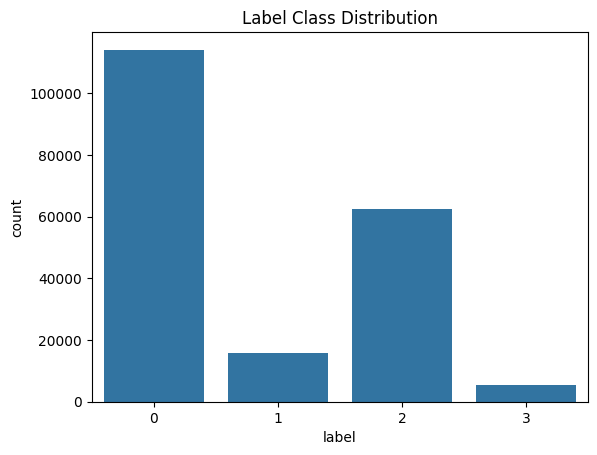

In [116]:
#Distribution of the target label
sns.countplot(x="label", data=train)
plt.title("Label Class Distribution")
plt.show()

* Label 0 is the most frequent.
* Label 2 is the second largest.
* The model may become biased towards zero.
* The dataset is imbalanced.

## Categorical features distribution

Countplot gives the count of the number of rows belonging to each category.

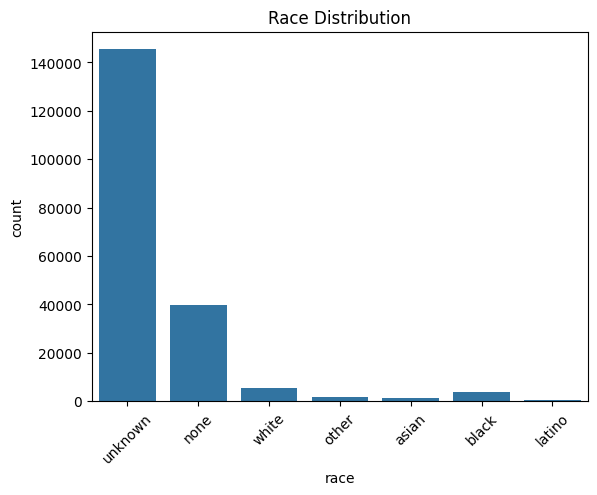

In [117]:
#Distribution of the race feature
sns.countplot(x="race", data=train)
plt.xticks(rotation=45)
plt.title("Race Distribution")
plt.show()

* 74% of the race column is unknown category.
* these features may have low predictive power.
* none is the next frequent race.

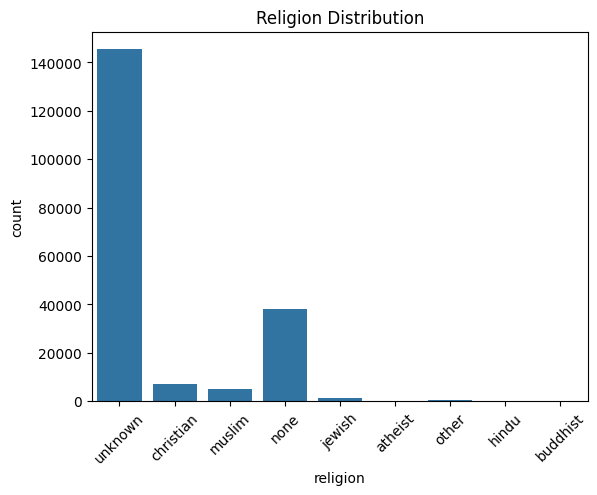

In [118]:
#Distribution of the religion feature
sns.countplot(x="religion", data=train)
plt.xticks(rotation=45)
plt.title("Religion Distribution")
plt.show()

* 74% of the religion column is unknown category.
* info from religion feature is less.

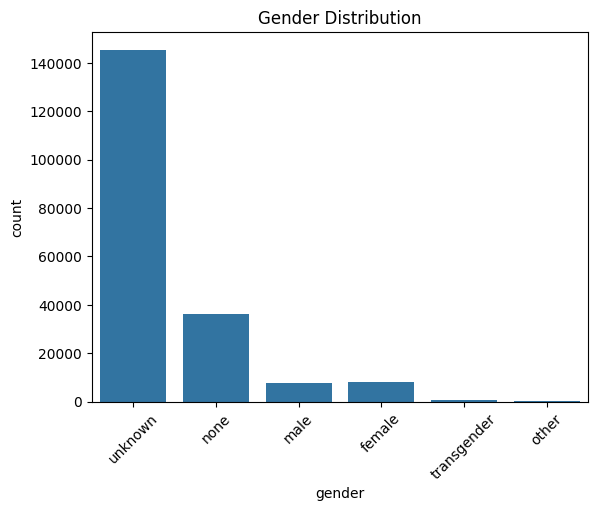

In [119]:
#Distribution of the gender variable
sns.countplot(x="gender", data=train)
plt.xticks(rotation=45)
plt.title("Gender Distribution")
plt.show()

* 74% of the gender column is unknown category.

## Numerical features distribution

### **Histogram Distributions**

Histogram plots help in visualizing the distribution of data to accordingly process them.

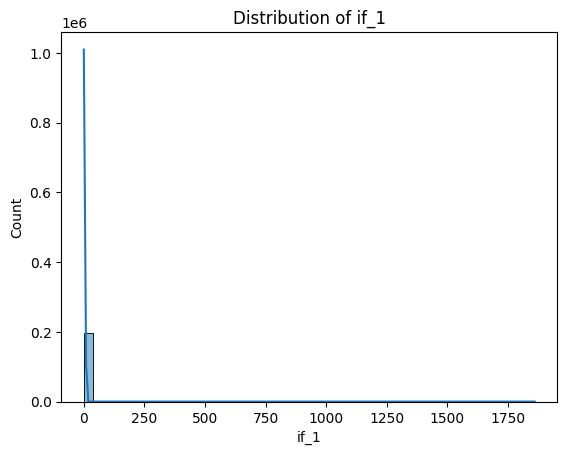

In [120]:
#Distribution of if_1 feature
sns.histplot(train["if_1"], bins=50,kde=True)
plt.title("Distribution of if_1")
plt.show()

 * right skewed distribution
 * majority of values near zero.

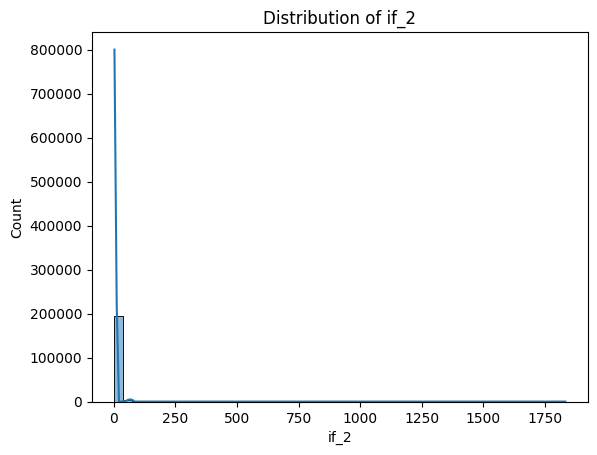

In [121]:
#Distribution of if_2 feature
sns.histplot(train["if_2"], bins=50,kde=True)
plt.title("Distribution of if_2")
plt.show()

 * right skewed distribution
 * majority of values near zero.

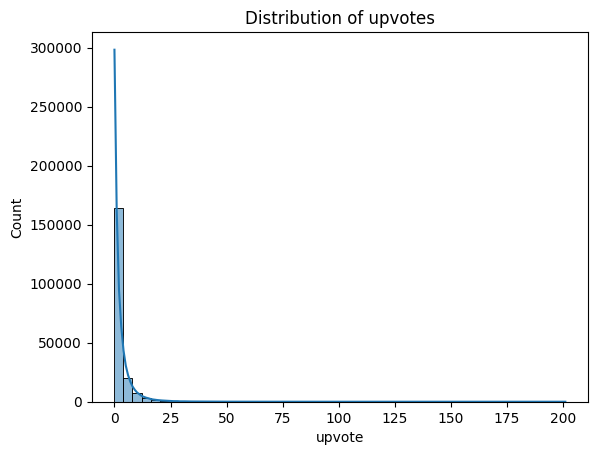

In [122]:
#Distribution of upvotes feature
sns.histplot(train["upvote"], bins=50,kde=True)
plt.title("Distribution of upvotes")
plt.show()

 * right skewed distribution
 * most posts have very low upvotes.
 * few have very high upvotes.

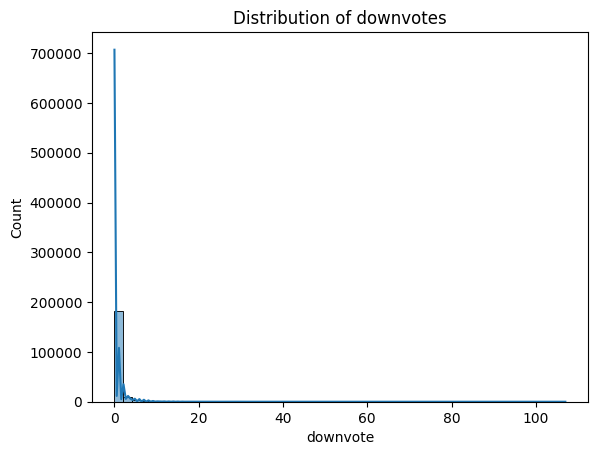

In [123]:
#Distribution of downvotes feature
sns.histplot(train["downvote"], bins=50,kde=True)
plt.title("Distribution of downvotes")
plt.show()

* right skewed distribution
 * few large outliers 
 * most have samll number of downvotes.

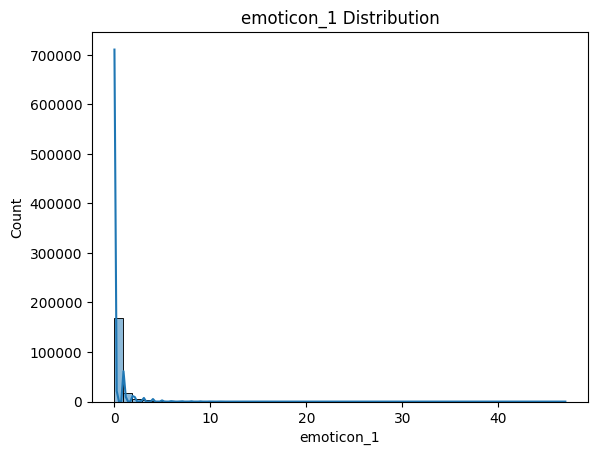

In [124]:
#Distribution of emoticon_1 feature
sns.histplot(train["emoticon_1"], bins=50,kde=True)
plt.title("emoticon_1 Distribution")
plt.show()

* mostly zero.
* few comments contain many emoticons.
* most comments do not contain emoticons.

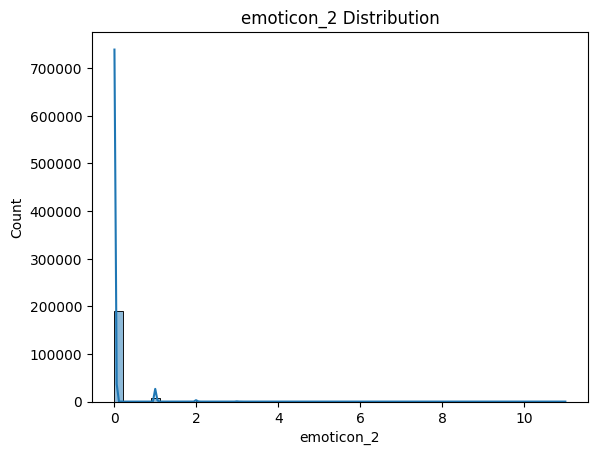

In [125]:
#Distribution of emoticon_2 feature
sns.histplot(train["emoticon_2"], bins=50,kde=True)
plt.title("emoticon_2 Distribution")
plt.show()

* mostly zero.
* few comments contain many emoticons.
* most comments do not contain emoticons.

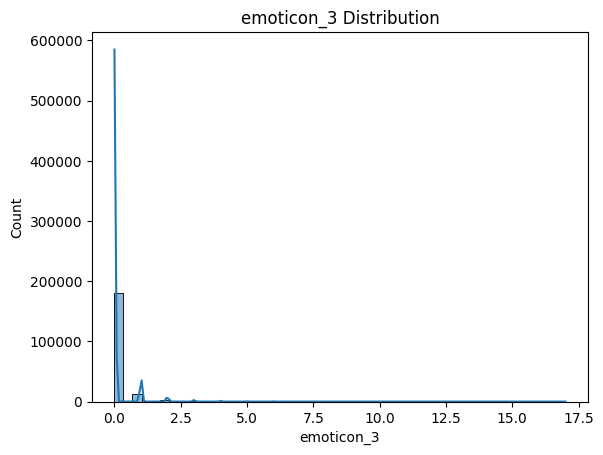

In [126]:
#Distribution of emoticon_3 feature
sns.histplot(train["emoticon_3"], bins=50,kde=True)
plt.title("emoticon_3 Distribution")
plt.show()

* mostly zero.
* few comments contain many emoticons.
* most comments do not contain emoticons.

The above plots imply that these features are right skewed, majority of values near zero and log transformation is applied to reduce skewness .

### **Log transformed Histogram distributions**

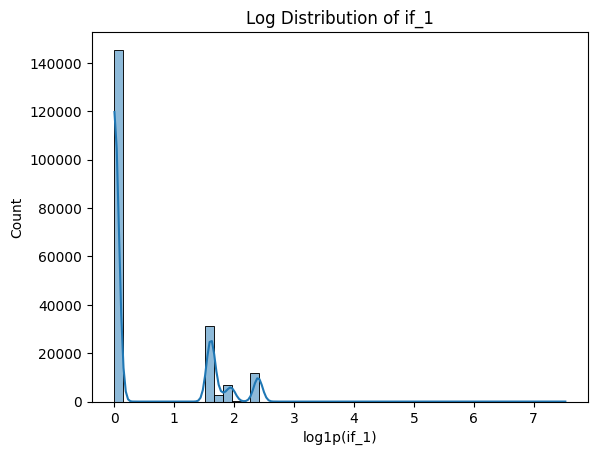

In [127]:
#Log distribution of if_1 feature
sns.histplot(np.log1p(train['if_1']), bins=50, kde=True)
plt.title('Log Distribution of if_1')
plt.xlabel('log1p(if_1)')
plt.show()

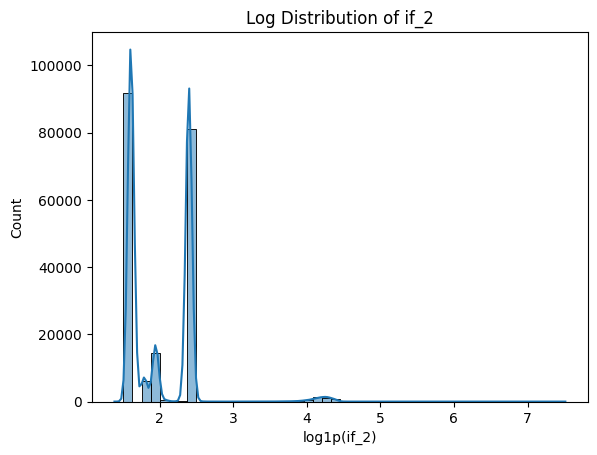

In [128]:
#Log distribution of if_2 feature
sns.histplot(np.log1p(train['if_2']), bins=50, kde=True)
plt.title('Log Distribution of if_2')
plt.xlabel('log1p(if_2)')
plt.show()

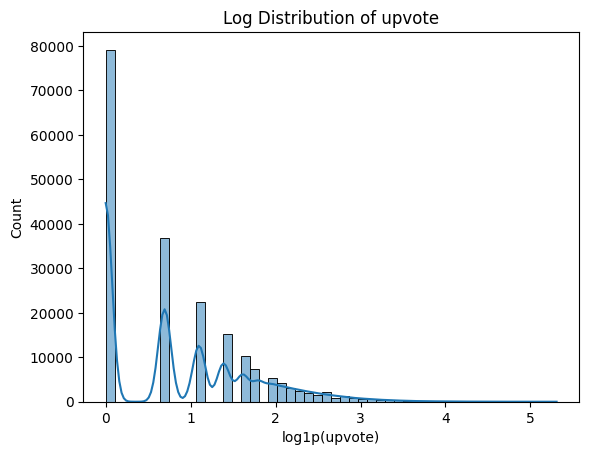

In [129]:
#Log distribution of upvote feature
sns.histplot(np.log1p(train['upvote']), bins=50, kde=True)
plt.title('Log Distribution of upvote')
plt.xlabel('log1p(upvote)')
plt.show()

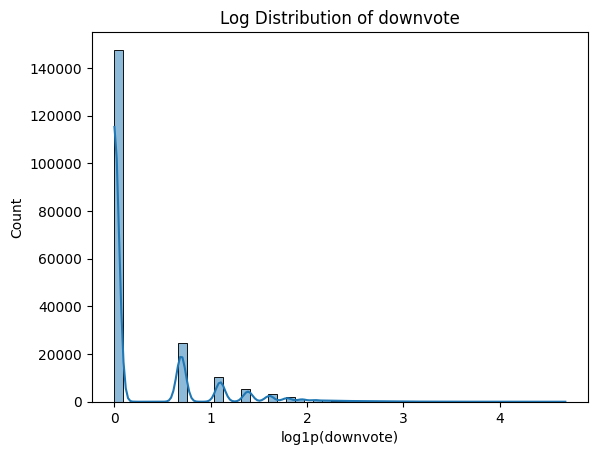

In [130]:
#Log distribution of downvote feature
sns.histplot(np.log1p(train['downvote']), bins=50, kde=True)
plt.title('Log Distribution of downvote')
plt.xlabel('log1p(downvote)')
plt.show()

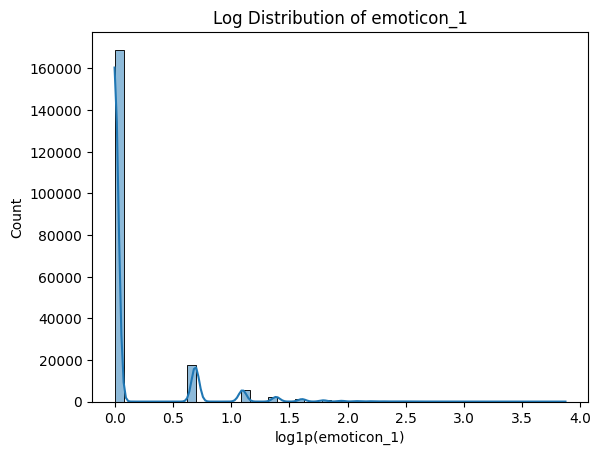

In [131]:
#Log distribution of emoticon_1 feature
sns.histplot(np.log1p(train['emoticon_1']), bins=50, kde=True)
plt.title('Log Distribution of emoticon_1')
plt.xlabel('log1p(emoticon_1)')
plt.show()

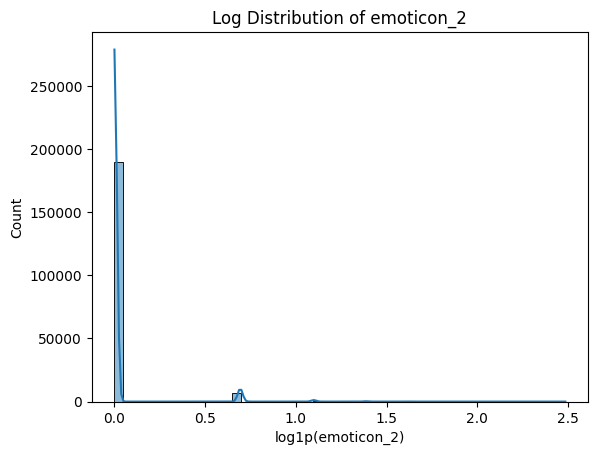

In [132]:
#Log distribution of emoticon_2 feature
sns.histplot(np.log1p(train['emoticon_2']), bins=50, kde=True)
plt.title('Log Distribution of emoticon_2')
plt.xlabel('log1p(emoticon_2)')
plt.show()

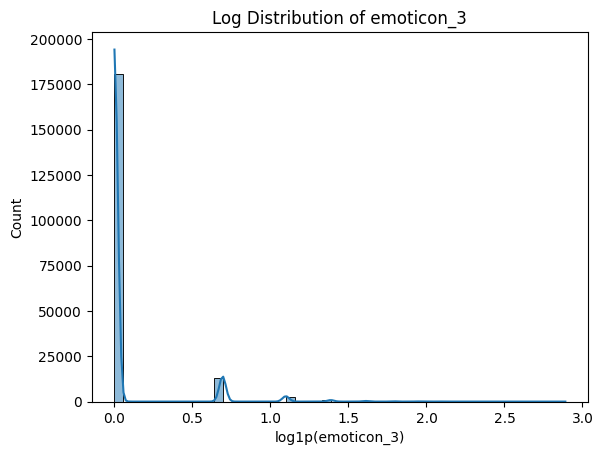

In [133]:
#Log distribution of emoticon_3 feature
sns.histplot(np.log1p(train['emoticon_3']), bins=50, kde=True)
plt.title('Log Distribution of emoticon_3')
plt.xlabel('log1p(emoticon_3)')
plt.show()

# ***Feature Engineering***

New features are added to improve the model's performance.

In [139]:
#disability column is converted to int type
for df in [train,test]:
    df['disability']=df['disability'].astype(int)

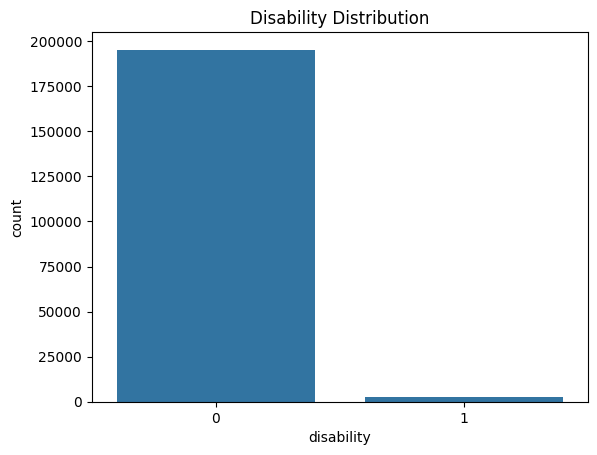

In [140]:
#Distribution of disbality feature
sns.countplot(x="disability", data=train)
plt.title("Disability Distribution")
plt.show()

* most are not disabled.

In [141]:
# Comment Length column is created
for df in [train, test]:
    df["comment"] = df["comment"].str.lower()
    df['comment_length'] = df['comment'].str.len()

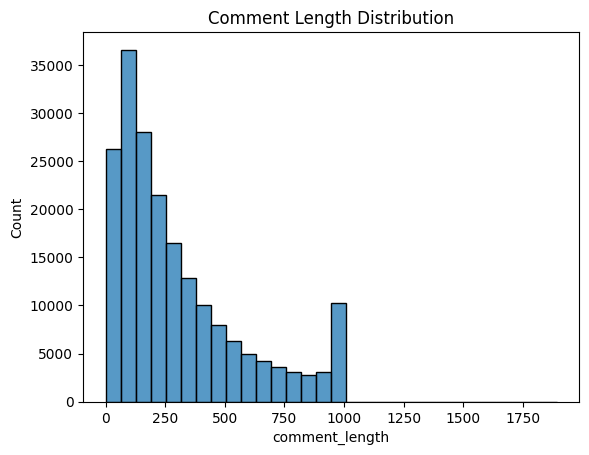

In [142]:
#Distribution of comment length feature (explanations)
sns.histplot(train['comment_length'], bins=30)
plt.title(f"Comment Length Distribution")
plt.show()

 * most comments are short

In [143]:
#Datetime features from the created_date column are created to identify time based patterns
for df in [train, test]:
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["hour"] = df["created_date"].dt.hour
    df["day"] = df["created_date"].dt.dayofweek
    df["date"] = df["created_date"].dt.day
    df["month"] = df["created_date"].dt.month
    df["year"] = df["created_date"].dt.year
    df["is_weekend"] = df["day"].isin([5,6]).astype(int)
    df['time_of_day'] = df['hour'].apply(lambda h: 
    'Morning' if 6 <= h < 12 else 
    'Afternoon' if 12 <= h < 18 else 
    'Evening' if 18 <= h < 21 else 
    'Night')

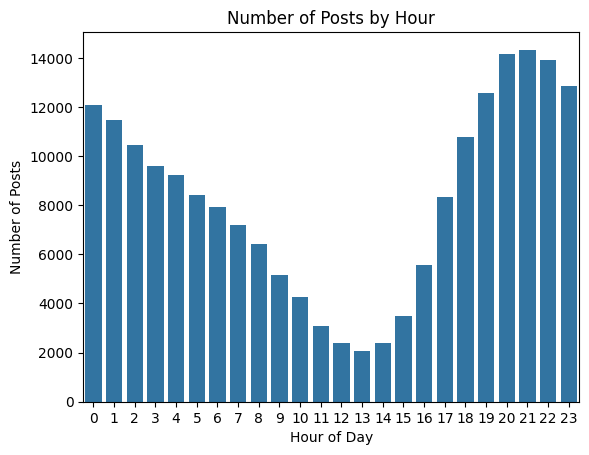

In [144]:
#Distribution of posts by hour of the day
sns.countplot(x='hour', data=train)
plt.title("Number of Posts by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Posts")
plt.show()

* comments peak in the night and very few in the midday.

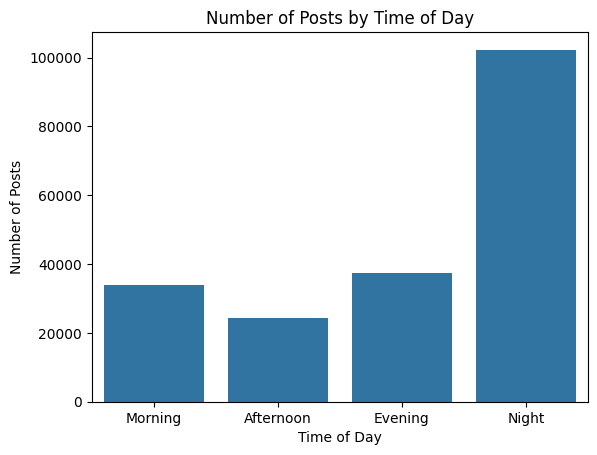

In [145]:
#Distribution of posts by time of the day
sns.countplot(x='time_of_day', data=train, order=['Morning','Afternoon','Evening','Night'])
plt.title("Number of Posts by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Posts")
plt.show()

* comments peak in the night.

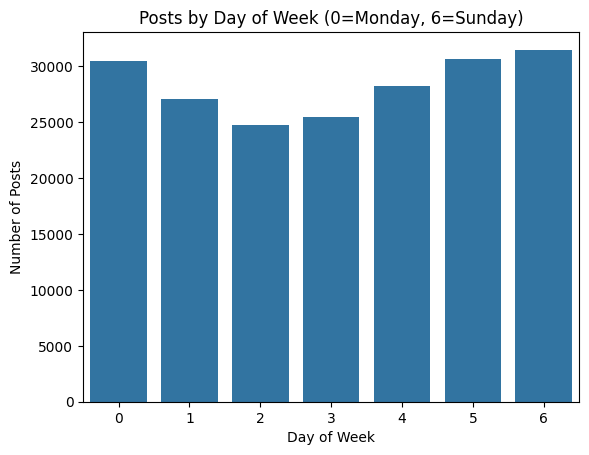

In [146]:
#Distribution of posts by day of the week
sns.countplot(x='day', data=train)
plt.title("Posts by Day of Week (0=Monday, 6=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Posts")
plt.show()

* comments are slightly higher inear the weekends than the midweek.

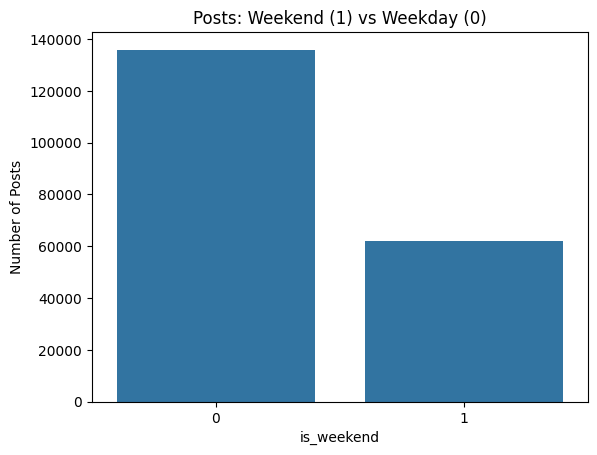

In [147]:
#Distribution of posts by weekend vs weekday
sns.countplot(x='is_weekend', data=train)
plt.title("Posts: Weekend (1) vs Weekday (0)")
plt.xlabel("is_weekend")
plt.ylabel("Number of Posts")
plt.show()

* most comments are during the weekdays mostly during night time

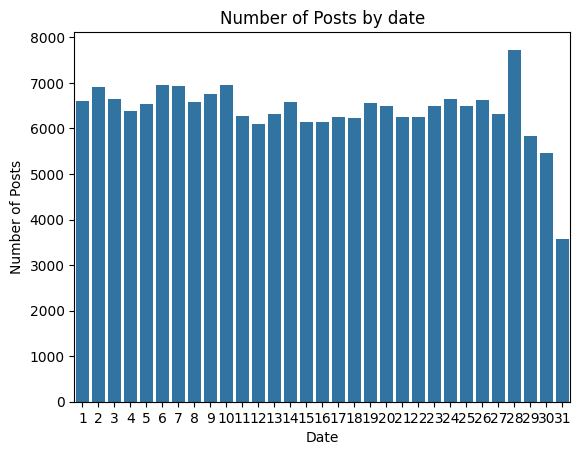

In [148]:
#Distribution of posts by date of the month
sns.countplot(x='date', data=train)
plt.title("Number of Posts by date")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.show()

* not much of a pattern across dates.

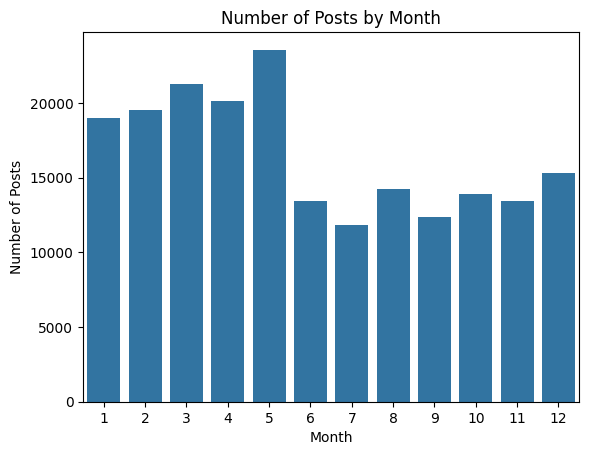

In [149]:
#Distribution of posts by month of the year
sns.countplot(x='month', data=train)
plt.title("Number of Posts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.show()

comments and posts are more in the beginning of the year and peaks during may which is vacation time.

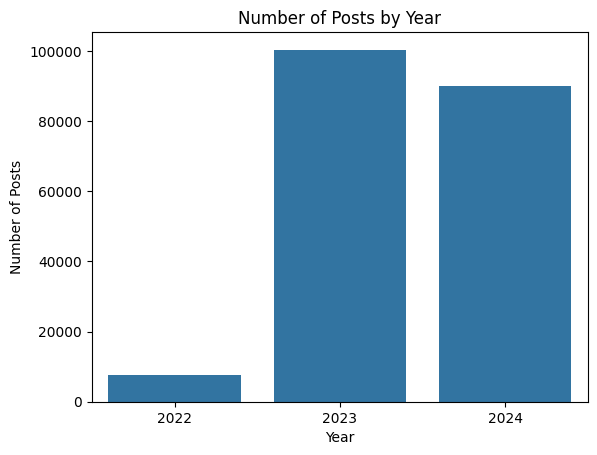

In [150]:
#Distribution of posts by year
sns.countplot(x='year', data=train)
plt.title("Number of Posts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.show()

* no pattern across years

In [151]:
#total emoticons feature is created (overall emotional intensity)
for df in [train, test]:
    df["total_emoticons"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]

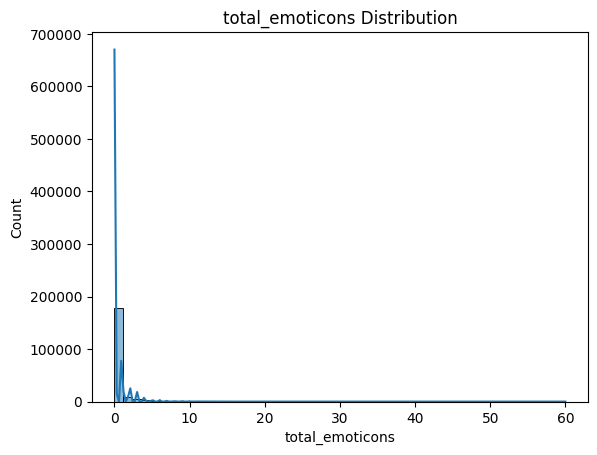

In [152]:
#Distribution of total_emoticons feature
sns.histplot(train["total_emoticons"], bins=50,kde=True)
plt.title("total_emoticons Distribution")
plt.show()

* right skewed
* mostly few or no emoticons

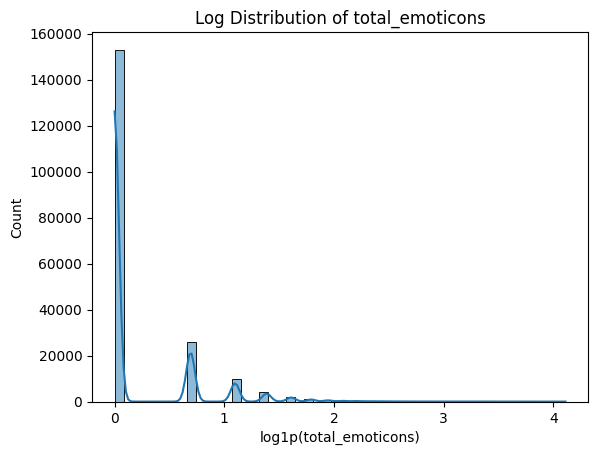

In [153]:
# Log distribution of total_emoticons feature
sns.histplot(np.log1p(train['total_emoticons']), bins=50, kde=True)
plt.title('Log Distribution of total_emoticons')
plt.xlabel('log1p(total_emoticons)')
plt.show()

In [154]:
# engagement and total_votes columns are created 
for df in [train, test]:
    df["engagement"] = df["upvote"] - df["downvote"] #net approval
    df["total_votes"] = df["upvote"] + df["downvote"] #overall activity

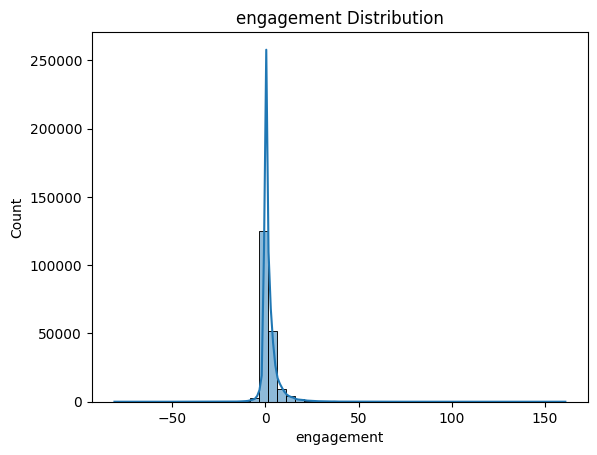

In [155]:
# #Distribution of engagement feature
sns.histplot(train["engagement"], bins=50,kde=True)
plt.title("engagement Distribution")
plt.show()

* most posts have received uvotes than downvotes

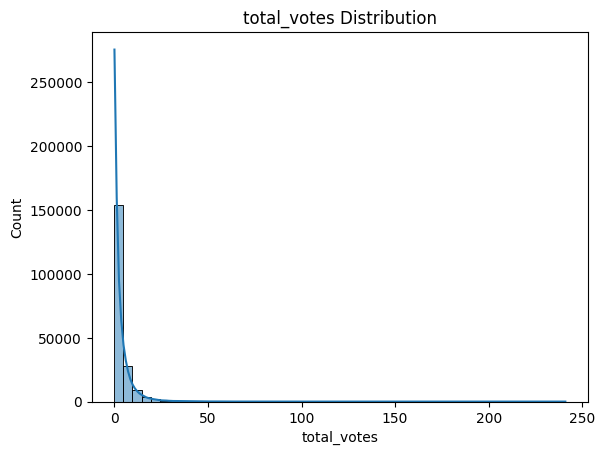

In [156]:
#Distribution of total_votes feature
sns.histplot(train["total_votes"], bins=50,kde=True)
plt.title("total_votes Distribution")
plt.show()

In [157]:
#binary feature of presence or absence of emoticons is created (neutral)
for df in [train,test]:
    df['has_emoticon_1']=(df['emoticon_1']>0).astype(int)
    df['has_emoticon_2']=(df['emoticon_2']>0).astype(int)
    df['has_emoticon_3']=(df['emoticon_3']>0).astype(int)

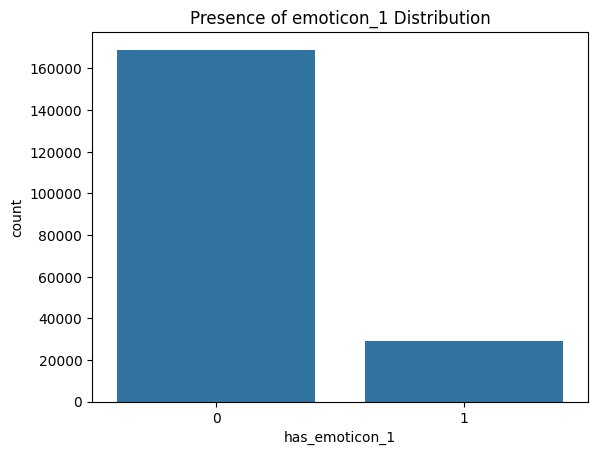

In [158]:
#Distribution of presence of emoticon_1 feature
sns.countplot(x='has_emoticon_1',data=train)
plt.title("Presence of emoticon_1 Distribution")
plt.show()

In [159]:
print("\t\tQuantitative statistics of the new numerical columns in the train dataset")
print("\n")
#post_id and label are not considered
print(train[['comment_length','total_emoticons', 'engagement','total_votes','has_emoticon_1','has_emoticon_2','has_emoticon_3']].describe())
print("\n")
print("\t\tQuantitative statistics of the new numerical columns in the test dataset")
print("\n")
print(test[['comment_length','total_emoticons', 'engagement','total_votes','has_emoticon_1','has_emoticon_2','has_emoticon_3']].describe())

		Quantitative statistics of the new numerical columns in the train dataset


       comment_length  total_emoticons     engagement    total_votes  \
count   198000.000000    198000.000000  198000.000000  198000.000000   
mean       302.909364         0.449177       1.941581       3.274369   
std        266.441749         1.253545       4.819638       6.019216   
min          0.000000         0.000000     -81.000000       0.000000   
25%        102.000000         0.000000       0.000000       0.000000   
50%        211.000000         0.000000       1.000000       1.000000   
75%        419.000000         0.000000       3.000000       4.000000   
max       1892.000000        60.000000     161.000000     241.000000   

       has_emoticon_1  has_emoticon_2  has_emoticon_3  
count   198000.000000   198000.000000   198000.000000  
mean         0.146071        0.040955        0.086692  
std          0.353178        0.198185        0.281384  
min          0.000000        0.000000        0.00

In [160]:
#Correlation matrix of all the numerical features
numeric_columns = train.select_dtypes(include=["int64"]).columns.tolist()
#colums with numeric type but not meaningful for correlation are removed
numeric_columns.remove("label")
numeric_columns.remove("post_id")
numeric_columns.remove("disability")
numeric_columns.remove("is_weekend")

<Axes: >

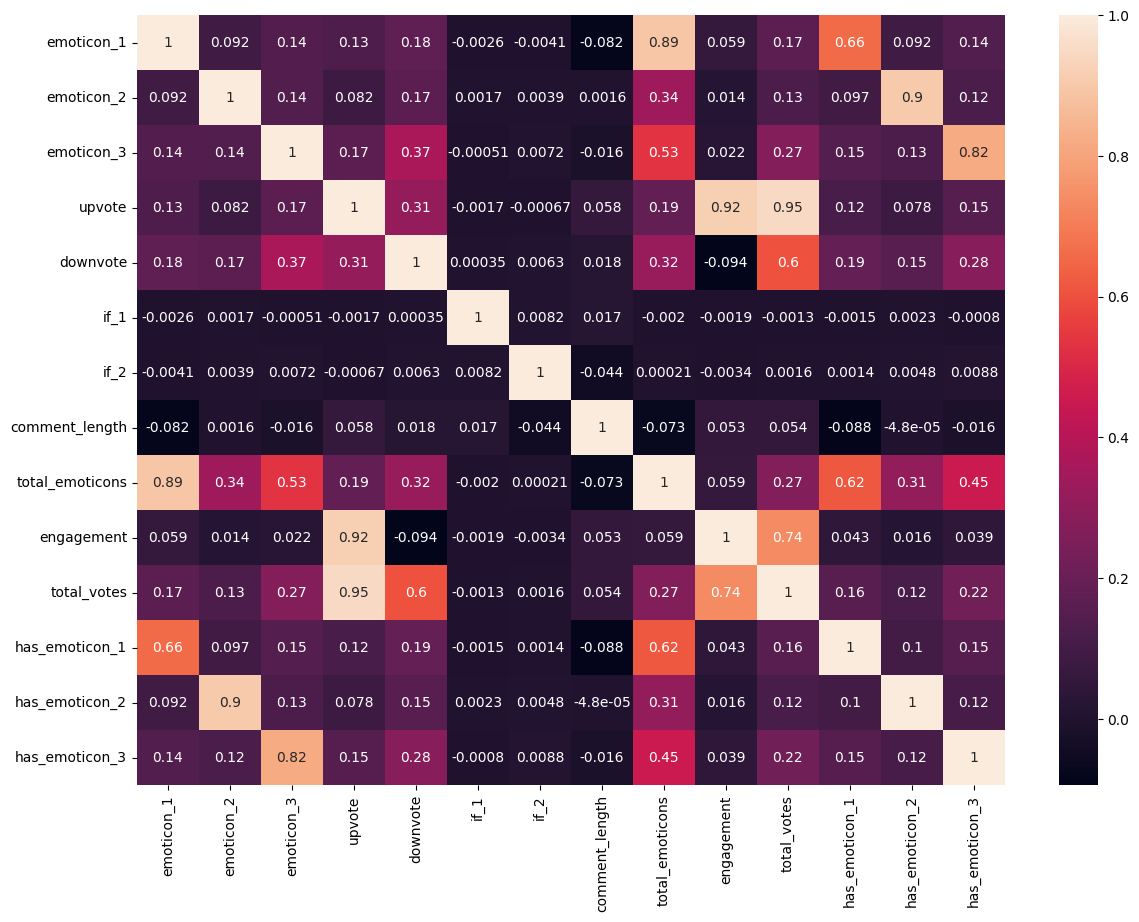

In [161]:
exp_set=train[numeric_columns]
corr_matrix=exp_set.corr()
plt.figure(figsize=(14, 10)) 
sns.heatmap(corr_matrix,annot=True)

* upvotes and downvotes show positive correlation
* emoticons have weak correlation with votes.
* emoticons slightly correlate with each other.
* more no of upvotes.
* emoticon_1 is higher than the other 2.

# ***Train-Validation split***

In [162]:
# Features not to be considered are drooped
#x and y datasets  are created
x = train.drop(columns=['post_id','created_date','label','date','hour','day', 'month','year','is_weekend'])  
y = train['label']    
x_test = test.drop(columns=['post_id','created_date','date','day', 'hour','month','year','is_weekend'])

In [163]:
#Splitting of the dataset into train and validation using train_test_split
x_train, x_val, y_train, y_val = train_test_split(
x, y,
test_size=0.2,
stratify=y,
random_state=42
)

In [164]:
print("Shape of the train dataset ",x_train.shape)
print("shape of the validation dataset ",x_val.shape)

Shape of the train dataset  (158400, 20)
shape of the validation dataset  (39600, 20)


# ***Data Preprocessing***

In [165]:
#Features are categorised based on their type for appropriate processing
skewed_features = ['upvote', 'downvote', 'total_votes', 'engagement','emoticon_1', 'emoticon_2', 'emoticon_3','if_1', 'if_2']
numerical_features = ['comment_length', 'total_emoticons']
categorical_features = ['race', 'religion', 'gender', 'disability', 'time_of_day']
text_features = 'comment'
binary_features = [ 'has_emoticon_1','has_emoticon_2','has_emoticon_3']

In [166]:
#log pipeline for the log features is created
#negative and null and infinite log values are made 0
def clean_log1p(x):
    x = np.array(x)
    x = np.nan_to_num(x, nan=0, posinf=0, neginf=0)  
    x = np.where(x < 0, 0, x )
    return np.log1p(x)

log_pipeline = Pipeline([('log', FunctionTransformer(clean_log1p)),('scaler', StandardScaler())])

In [167]:
#Pipeline for the numerical features is created
normal_pipeline = Pipeline([('scaler', StandardScaler())])

In [168]:
#pieline for the categorical features is created
categorical_pipeline = OneHotEncoder(handle_unknown='ignore')

In [169]:
#Text Vectorizer
word_tfidf = TfidfVectorizer(max_features=12000,ngram_range=(1,2),stop_words='english',min_df=5,max_df=0.9)
char_tfidf = TfidfVectorizer(analyzer='char',ngram_range=(3,5),max_features=5000)
#Pieline for the text features is created using feature union
text_pipeline = FeatureUnion([('word', word_tfidf),('char', char_tfidf)])

In [170]:
#Column transformer for all the features together is created
preprocessor = ColumnTransformer(transformers=
[
('log_num', log_pipeline, skewed_features),
('num', normal_pipeline, numerical_features),
('bin', 'passthrough', binary_features),
('cat', categorical_pipeline, categorical_features),
('text', text_pipeline, text_features)
])

# ***Training Models***

## LGBM model

In [171]:
# #baseline model pieline before hpt tuning
# lgbm_pieline_nhpt = Pipeline([('preprocessor', preprocessor),('classifier', lgb.LGBMClassifier())])
# #fitting the model on the train data
# lgbm_pieline_nhpt.fit(x_train, y_train)

In [172]:
# # predicting the created model on validation data
# y_predicted_lgbm_nhpt = lgbm_pieline_nhpt.predict(x_val)

In [173]:
# # Checking for model's performance
# print("LightGBM Accuracy before HPT tuning:", accuracy_score(y_val, y_predicted_lgbm_nhpt))
# print(classification_report(y_val, y_predicted_lgbm_nhpt))

In [174]:
# # # confusion matrix is computed
# confusion_matrix_lgbm_nhpt = confusion_matrix(y_val, y_predicted_lgbm_nhpt)

# # # Plotting the matrix
# plt.figure(figsize=(8,6))
# sns.heatmap(confusion_matrix_lgbm_nhpt, annot=True, fmt='d', cmap='Blues',xticklabels=[0,1,2,3],yticklabels=[0,1,2,3])

# plt.xlabel("Predicted Labels")
# plt.ylabel("Actual Labels")
# plt.title("Confusion Matrix of lgbm before tuning")
# plt.show()

In [175]:
# #LGBM model as a pipeline is created
# lgb_pipeline_hpt = Pipeline([
# ('preprocessor', preprocessor),
# ('classifier', lgb.LGBMClassifier(
# class_weight='balanced',
# early_stopping_rounds=30,
# random_state=42
# ))])

In [176]:
# #Hyperparameter Tuning
# parametrs_lgbm_hpt = {
# 'classifier__n_estimators': randint(50, 150),
# 'classifier__learning_rate': uniform(0.05, 0.15),
# 'classifier__num_leaves': randint(20, 64),
# 'classifier__max_depth': randint(3, 8),
# 'classifier__subsample': uniform(0.7, 0.3),
# 'classifier__colsample_bytree': uniform(0.7, 0.3),
# }

In [177]:
# #cross validation
# cross_validation_lgbm_hpt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [178]:
# # Randomized search is used to find the best parameters
# lgb_search_random_hpt = RandomizedSearchCV(
# lgb_pipeline_hpt,
# param_distributions=parameters_lgbm_hpt,
# n_iter=5,
# cv=cross_validation_lgbm_hpt,
# scoring='accuracy',
# n_jobs=-1,
# random_state=42
# )

In [179]:
# # #Model is fit on the training data
# lgb_search_random_hpt.fit(x_train, y_train)

# # #best estimator for the model is determined
# lgb_best_hpt = lgb_search_random_hpt.best_estimator_

# # #Model is evaluated on the validation data
# y_predicted_lgbm_hpt = lgb_best_hpt.predict(x_val)

In [180]:
# # # Model scores is calculated
# print("LightGBM Tuned Accuracy:", accuracy_score(y_val, y_predicted_lgbm_hpt))
# print(classification_report(y_val, y_predicted_lgbm_hpt))

In [181]:
# # # confusion matrix is computed after hpt tuning
# confusion_matrix_hpt_lgbm = confusion_matrix(y_val, y_predicted_lgbm_hpt)

# # # Plotting the matrix
# plt.figure(figsize=(8,6))
# sns.heatmap(confusion_matrix_hpt_lgbm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3],yticklabels=[0,1,2,3])

# plt.xlabel("Predicted Labels")
# plt.ylabel("Actual Labels")
# plt.title("Confusion Matrix of lgbm after tuning")
# plt.show()

In [182]:
# #Model is run on the train dataset
# y_test_predicted_lgbm_hpt = lgb_best_hpt.predict(x_test)

In [183]:
# #Label column of sample file is replaced
# sample['label'] = y_test_predicted_lgbm_hpt

In [184]:
# # # LGBM
# lgb_accuracy = accuracy_score(y_val, y_predicted_lgbm_hpt)
# lgb_f1_score = f1_score(y_val, y_predicted_lgbm_hpt, average='weighted')
# print(lgb_accuracy)
# print(lgb_f1_score)

## Random Forest

In [185]:
#random forest pipeline before hpt tuning
# rf_pipeline_nhpt = Pipeline([ ('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) ])

In [186]:
#pieline is fit on the train dataset
# rf_pipeline_nhpt.fit(x_train, y_train) 

In [187]:
#pieline is predicted on the validation dataset
#rf_predicted_nhpt = rf_pipeline_nhpt.predict(x_val)

In [188]:
# model's performance is assessed
#print("Random Forest Default Accuracy:", accuracy_score(y_val, rf_predicted_nhpt)) 
# print(classification_report(y_val, rf_predicted_nhpt))

In [189]:
# # confusion matrix is plotted
# confusion_matrix_rf_nhpt = confusion_matrix(y_val, rf_predicted_nhpt)

# # Ploting the matrix 
# plt.figure(figsize=(8,6))
# sns.heatmap(confusion_matrix_rf_nhpt, annot=True, fmt='d', cmap='Blues',xticklabels=[0,1,2,3],yticklabels=[0,1,2,3])

# plt.xlabel("Predicted Labels")
# plt.ylabel("Actual Labels")
# plt.title("Confusion Matrix of random forest before tuning")
# plt.show()

In [190]:
# #parameters for tuning and cross valiadtion is set
# rf_parameters_hpt = { 'classifier__n_estimators': randint(100, 300), 'classifier__max_depth': randint(5, 15), 'classifier__min_samples_split': randint(2, 6), 'classifier__min_samples_leaf': randint(1, 3), }
# cross_validation_rf_hpt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# #random serch of parameters
# rf_search_random_hpt = RandomizedSearchCV( rf_pipeline_nhpt, param_distributions=rf_parameters_hpt, n_iter=5, cv=cross_validation_rf_hpt, scoring='accuracy', n_jobs=-1, random_state=42 )

In [191]:
#model is fit on the train dataset
# rf_search_random_hpt.fit(x_train, y_train) 

In [192]:
#best estimators are found
# rf_best_hpt = rf_search_random_hpt.best_estimator_

In [193]:
#best parametes are used to predict on the validation dataset
# rf_predicted_hpt = rf_best_hpt.predict(x_val)

In [194]:
#scores of the model
# print("Random Forest Tuned Accuracy:", accuracy_score(y_val, rf_predicted_hpt)) 
# print(classification_report(y_val, rf_predicted_hpt))

In [195]:
#model is then predicted on the unseen test dataset
# y_test_predicted_rf_hpt = rf_best_hpt.predict(x_test)

In [196]:
#sample file column label is replaced
# sample['label'] = y_test_predicted_rf_hpt

In [197]:
# Compute confusion matrix
# confusion_matrix_rf_hpt = confusion_matrix(y_val, rf_predicted_hpt)

# # Plot the matrix
# plt.figure(figsize=(8,6))
# sns.heatmap(confusion_matrix_rf_hpt, annot=True, fmt='d', cmap='Blues',xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])

# plt.xlabel("Predicted Labels")
# plt.ylabel("Actual Labels")
# plt.title("Confusion Matrix")
# plt.show()

In [198]:
# Random Forest scores
# rf_accuracy = accuracy_score(y_val, rf_predicted_hpt)
# rf_f1_score = f1_score(y_val, rf_predicted_hpt, average='weighted')

In [199]:
# print(rf_accuracy)
# print(rf_f1_score)

## XGBoost

In [200]:
# xgboost pipeline is created
xgb_pipeline_nhpt = Pipeline([ ('preprocessor', preprocessor), ('classifier', XGBClassifier(random_state=42,  eval_metric='mlogloss', n_jobs=1 )) ])

# the model is fit on the training data
# xgb_pipeline_nhpt.fit(x_train, y_train) 

# model is predicted on the validation data
# xgb_predicted_nhpt = xgb_pipeline_nhpt.predict(x_val)

# score before tuning 
# print("XGBoost Default Accuracy:", accuracy_score(y_val, xgb_predicted_nhpt)) 
# print(classification_report(y_val, xgb_predicted_nhpt))

In [201]:
# #hpt parameters and cross validation
xgb_parameters_hpt = { 'classifier__n_estimators': randint(50, 150),'classifier__max_depth': randint(3, 6), 'classifier__learning_rate': uniform(0.05, 0.15),'classifier__subsample': uniform(0.7, 0.2)}
cross_validation_xgb_hpt = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# #random search of the parameters
xgb_search_random_hpt = RandomizedSearchCV( xgb_pipeline_nhpt, param_distributions=xgb_parameters_hpt, n_iter=3, cv=cross_validation_xgb_hpt, scoring='accuracy', n_jobs=1, random_state=42 , verbose=2 )

In [202]:
#fit the model on the train dataset
xgb_search_random_hpt.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END classifier__learning_rate=0.10618101782710437, classifier__max_depth=3, classifier__n_estimators=64, classifier__subsample=0.846398788362281; total time= 5.6min
[CV] END classifier__learning_rate=0.10618101782710437, classifier__max_depth=3, classifier__n_estimators=64, classifier__subsample=0.846398788362281; total time= 5.5min
[CV] END classifier__learning_rate=0.13979877262955548, classifier__max_depth=5, classifier__n_estimators=132, classifier__subsample=0.7199949831636006; total time=14.6min
[CV] END classifier__learning_rate=0.13979877262955548, classifier__max_depth=5, classifier__n_estimators=132, classifier__subsample=0.7199949831636006; total time=14.5min
[CV] END classifier__learning_rate=0.11888733379488008, classifier__max_depth=3, classifier__n_estimators=149, classifier__subsample=0.7285733635843881; total time= 8.4min
[CV] END classifier__learning_rate=0.11888733379488008, classifier__max_depth=3, clas

RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('log_num',
                                                                               Pipeline(steps=[('log',
                                                                                                FunctionTransformer(func=<function clean_log1p at 0x7ae410f3c5e0>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['upvote',
                                                                                'downvote',
                                                                                'total_votes',
                                                                                'engagement',
                                                                                'emoticon_1',
                                                                                'emotic...
                                        'classifier__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ae46b19b740>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ae46b19b6e0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ae418ecd700>},
                   random_state=42, scoring='accuracy', verbose=2)

In [203]:
#finding best estimators
xgb_best_hpt = xgb_search_random_hpt.best_estimator_

In [204]:
# #predict on the validation data
xgb_predicted_hpt = xgb_best_hpt.predict(x_val) 

# #scores of the model
print("XGBoost Tuned Accuracy:", accuracy_score(y_val, xgb_predicted_hpt)) 
print(classification_report(y_val, xgb_predicted_hpt))

XGBoost Tuned Accuracy: 0.9077525252525253
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.74      0.76      3183
           2       0.83      0.92      0.87     12488
           3       0.77      0.39      0.52      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.75      0.78     39600
weighted avg       0.91      0.91      0.91     39600



In [205]:
# predict on unseen test dataset
y_test_predicted_xgb = xgb_best_hpt.predict(x_test)

In [206]:
# Random Forest scores
xgb_accuracy = accuracy_score(y_val, xgb_predicted_hpt)
xgb_f1_score = f1_score(y_val, xgb_predicted_hpt, average='weighted')

In [207]:
print(xgb_accuracy)
print(xgb_f1_score)

0.9077525252525253
0.9058693739032655


## Logistic Regression

In [208]:
#dummy model is created
# log_pipeline = Pipeline([ ('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42)) ])

In [209]:
# model is fit on train datset
#log_pipeline.fit(x_train, y_train)

#model is predicted on validation dataset
# y_predicted_log = log_pipeline.predict(x_val)

#scores of the model
# print("Baseline Model (Logistic Regression) Accuracy:", accuracy_score(y_val, y_predicted_log)) 
# print(classification_report(y_val, y_predicted_log))

# ***Comparison of Models Performance***

In [215]:
results = {
"LGBM": {
"Accuracy": 0.91,
"F1": 0.91
},
"XGBoost": {
"Accuracy": 0.9077525252525253,
"F1": 0.9058693739032655,
},
"RandomForest": {
"Accuracy": 0.6742171717171718,
"F1": 0.6108273539311102
}
}

In [216]:
df = pd.DataFrame(results).T
print(df)

              Accuracy        F1
LGBM          0.910000  0.910000
XGBoost       0.907753  0.905869
RandomForest  0.674217  0.610827


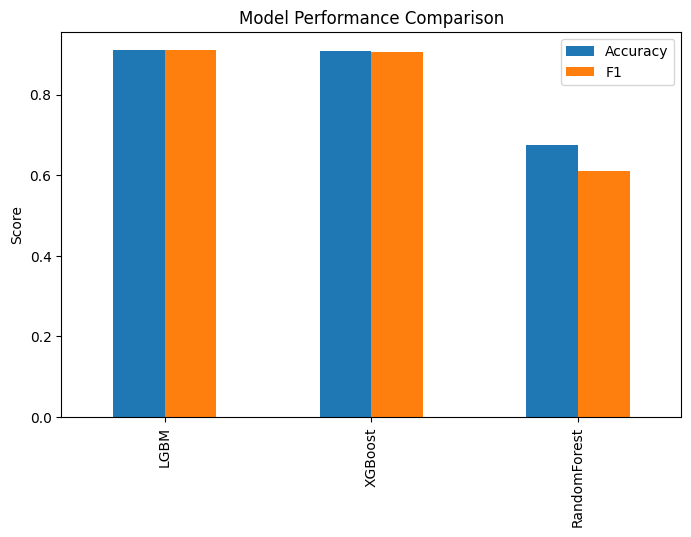

In [218]:
df.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [213]:
# CSV file is created
sample.to_csv('submission.csv', index=False)